here our goal is to get the best cnn for hand written digit classsification using tensorflow from scratch


In [1]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

In [2]:
from  keras.layers import *

In [3]:
# laoding the data
mnist = tf.keras.datasets.mnist
(X_train,y_train),(X_test,y_test) = mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [4]:
# normalising each values
X_train = tf.keras.utils.normalize(X_train,axis=1) # also X_train / 255. same result
X_test = tf.keras.utils.normalize(X_test,axis=1)

In [5]:
callback = tf.keras.callbacks.EarlyStopping(monitor='loss',
                                            patience=3)

In [6]:
# model building
model = tf.keras.models.Sequential()
model.add(tf.keras.layers.Flatten(input_shape=(28,28)))
model.add(tf.keras.layers.Dense(128,activation='relu'))
model.add(tf.keras.layers.Dropout(0.1))
model.add(tf.keras.layers.BatchNormalization())
model.add(tf.keras.layers.Dense(128,activation='relu'))
model.add(tf.keras.layers.Dropout(0.1))
model.add(tf.keras.layers.BatchNormalization())
model.add(tf.keras.layers.Dense(64,activation='relu'))
model.add(tf.keras.layers.Dropout(0.1))
model.add(tf.keras.layers.BatchNormalization())
model.add(tf.keras.layers.Dense(10,activation='softmax'))

model.compile(optimizer='adam',loss='sparse_categorical_crossentropy',metrics=['accuracy'])

training_history = model.fit(X_train,y_train,epochs=10,validation_data=(X_test,y_test),callbacks=[callback])

model.evaluate(X_test,y_test)

Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 23s 9ms/step - accuracy: 0.8939 - loss: 0.3532 - val_accuracy: 0.9555 - val_loss: 0.1498
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 16s 6ms/step - accuracy: 0.9430 - loss: 0.1904 - val_accuracy: 0.9631 - val_loss: 0.1153
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.9536 - loss: 0.1540 - val_accuracy: 0.9680 - val_loss: 0.1057
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.9597 - loss: 0.1353 - val_accuracy: 0.9700 - val_loss: 0.0988
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.9641 - loss: 0.1181 - val_accuracy: 0.9721 - val_loss: 0.0895
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.9674 - loss: 0.1052 - val_accuracy: 0.9735 - val_loss: 0.0851
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.9686 - loss: 0.1010 - val_accuracy: 0.9752 - val_loss: 0.0815
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 12s 6ms/step - accuracy: 0.9725 - loss: 0

[0.07369258999824524, 0.9768000245094299]

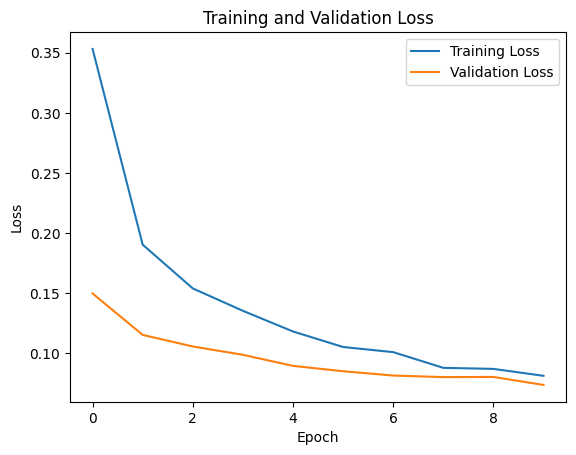

In [7]:
plt.plot(training_history.history['loss'], label='Training Loss')
plt.plot(training_history.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [8]:
test_img = X_test[0]

In [9]:
pred = model.predict(test_img.reshape(1,28,28))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 140ms/step


In [10]:
np.argmax(pred)

np.int64(7)

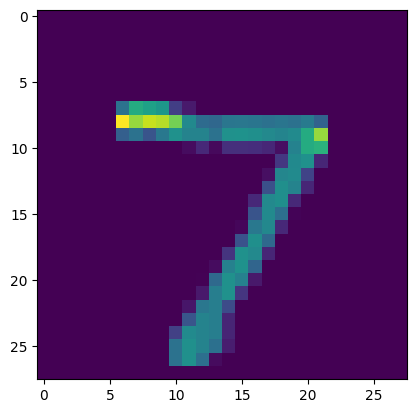

In [11]:
plt.imshow(test_img)

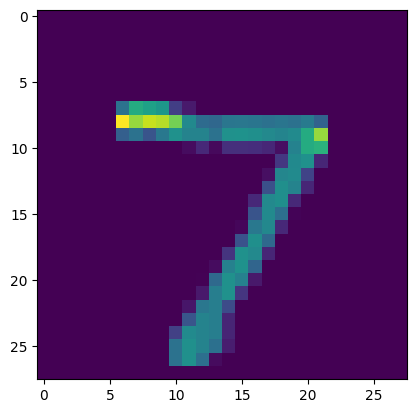

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
correct


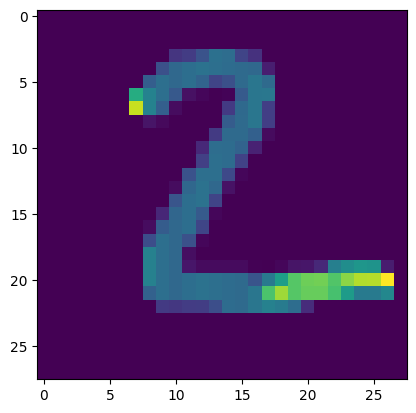

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
correct


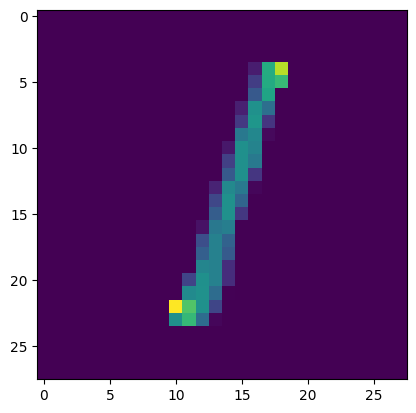

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
correct


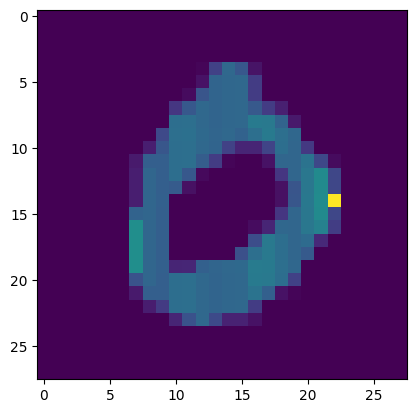

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
correct


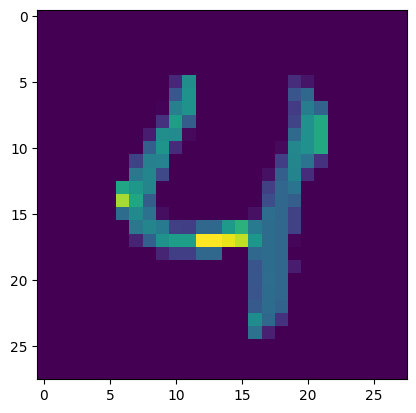

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
correct


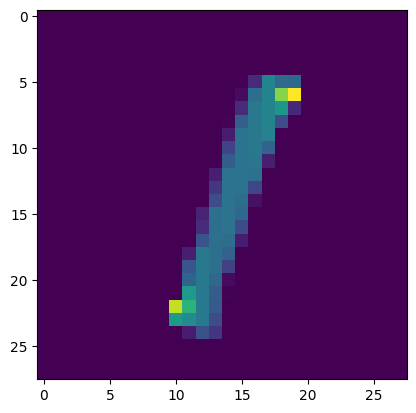

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
correct


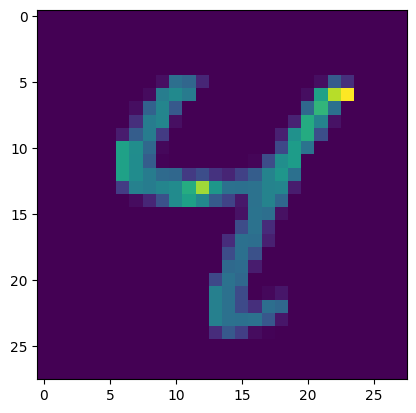

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
correct


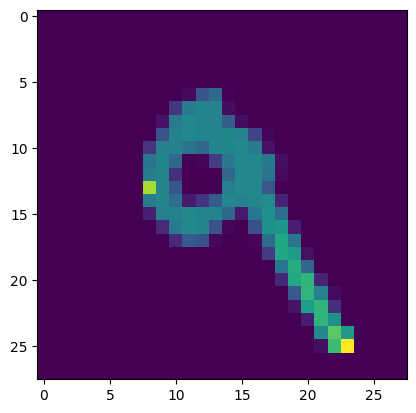

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
correct


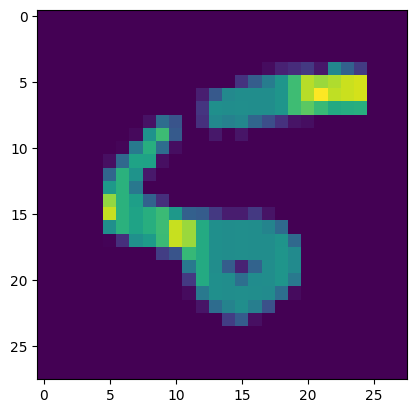

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
correct


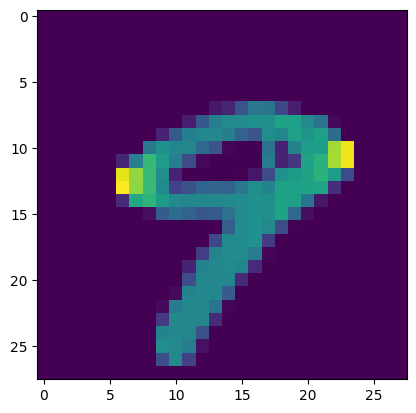

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
correct


In [12]:
def check_10_imges():
  correct_count = 0
  for i in range(10):
    plt.imshow(X_test[i])
    plt.show()

    if np.argmax(model.predict(X_test[i].reshape(1,28,28))) == y_test[i]:
      print('correct')
      correct_count += 1
    else:
      print('wrong')

obj = check_10_imges();

In [13]:
model.save('my_model.keras')

In [14]:
model = tf.keras.models.load_model('my_model.keras')

In [15]:
import cv2
import numpy as np

def preprocess_custom_image(image_path):
    img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)

    img = cv2.resize(img, (28, 28))

    if img[0, 0] > 127:
        img = cv2.bitwise_not(img)

    img = img.astype('float32') / 255.0

    img = np.expand_dims(img, axis=0)

    return img

# Test your new image
processed_img = preprocess_custom_image('test2_img.png')
prediction = model.predict(processed_img)
predicted_digit = np.argmax(prediction)
print(f"Predicted Digit: {predicted_digit}")


error: OpenCV(4.13.0) /io/opencv/modules/imgproc/src/resize.cpp:4208: error: (-215:Assertion failed) !ssize.empty() in function 'resize'


now same thing for mnst cloths data


In [ ]:
# laoding the data
(X_train,y_train),(X_test,y_test) = keras.datasets.fashion_mnist.load_data()

In [ ]:
# normalising each values
X_train = tf.keras.utils.normalize(X_train,axis=1) # also X_train / 255. same result
X_test = tf.keras.utils.normalize(X_test,axis=1)

In [ ]:
callback = tf.keras.callbacks.EarlyStopping(monitor='loss',
                                            patience=3)

In [ ]:
# model building
model = tf.keras.models.Sequential()
model.add(tf.keras.layers.Flatten(input_shape=(28,28)))
model.add(tf.keras.layers.Dense(128,activation='relu'))
model.add(tf.keras.layers.Dropout(0.1))
model.add(tf.keras.layers.BatchNormalization())
model.add(tf.keras.layers.Dense(128,activation='relu'))
model.add(tf.keras.layers.Dropout(0.1))
model.add(tf.keras.layers.BatchNormalization())
model.add(tf.keras.layers.Dense(64,activation='relu'))
model.add(tf.keras.layers.Dropout(0.1))
model.add(tf.keras.layers.BatchNormalization())
model.add(tf.keras.layers.Dense(10,activation='softmax'))

model.compile(optimizer='adam',loss='sparse_categorical_crossentropy',metrics=['accuracy'])

training_history = model.fit(X_train,y_train,epochs=100,validation_data=(X_test,y_test),callbacks=[callback])

model.evaluate(X_test,y_test)

In [ ]:
plt.plot(training_history.history['loss'], label='Training Loss')
plt.plot(training_history.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [ ]:
def check_10_imges():
  correct_count = 0
  for i in range(10):
    plt.imshow(X_test[i])
    plt.show()

    if np.argmax(model.predict(X_test[i].reshape(1,28,28))) == y_test[i]:
      print('correct')
      correct_count += 1
    else:
      print('wrong')

obj = check_10_imges();

In [ ]:
from sklearn.metrics import roc_curve, auc, roc_auc_score
from sklearn.preprocessing import LabelBinarizer

# Get predicted probabilities for X_test
y_pred_proba = model.predict(X_test)

# One-hot encode true labels (y_test)
label_binarizer = LabelBinarizer()
y_test_one_hot = label_binarizer.fit_transform(y_test)

# Number of classes
n_classes = y_test_one_hot.shape[1]

# Compute ROC curve and ROC area for each class
fpr = dict()
tpr = dict()
roc_auc = dict()

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test_one_hot[:, i], y_pred_proba[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Plot all ROC curves
plt.figure(figsize=(10, 8))
for i in range(n_classes):
    plt.plot(fpr[i], tpr[i], label=f'ROC curve of class {i} (area = {roc_auc[i]:.2f})')

plt.plot([0, 1], [0, 1], 'k--', label='Random classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve for Multi-class')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()


In [ ]:
import cv2
import numpy as np

def preprocess_custom_image(image_path):
    img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)

    img = cv2.resize(img, (28, 28))

    if img[0, 0] > 127:
        img = cv2.bitwise_not(img)

    img = img.astype('float32') / 255.0

    img = np.expand_dims(img, axis=0)

    return img

# Test your new image
processed_img = preprocess_custom_image('test2_img.png')
prediction = model.predict(processed_img)
predicted_digit = np.argmax(prediction)
print(f"Predicted Digit: {predicted_digit}")